In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')

small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [3]:
# from langchain_openai import AzureChatOpenAI

# llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-2024-11-20',
#     api_version='2024-08-01-preview',   
# )

# small_llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-mini-2024-07-18',
#     api_version='2024-08-01-preview',
# )

In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [6]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\cleft\AppData\Local\Temp\ipykernel_13388\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\cleft\AppData\Local\Temp\ipykernel_13388\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x00000254F23D3ED0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000254F23D3ED0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x00000254F23D3ED0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000254F23D3ED0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x00000254F23D3ED0>)]

In [8]:
# from langchain.agents import load_tools

# tools = load_tools(
#     ["arxiv"],
# )
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

loaded_tool_list = [arxiv]

In [9]:
loaded_tool_list


[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000))]

In [10]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
        collection_name="real_estate_tax",
        persist_directory="./real_estate_tax_collection",
        embedding_function=embeddings
    )

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to April 2026'
)


In [11]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list +loaded_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [12]:
# multiply.invoke({'a': 3, 'b': 5})

In [13]:
# from langchain_core.messages import HumanMessage

# ai_message = llm_with_tools.invoke('3에다 5를 더하면?')

In [14]:
# ai_message

In [15]:
# tool_node.invoke({'messages': [ai_message]})

In [16]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [17]:
from langchain_core.messages import SystemMessage


def agent(state: AgentState) -> AgentState:
    messages = state['messages']
    print(f'messages length == {len(messages)}')
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
        
    print(f'agent_messages_with_summary == {messages}')    
    response = llm_with_tools.invoke(messages)
    # print(f"agent messages == {response} ")
    
    return {'messages': [response]}

In [18]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
        chat_history: {messages}
        summary: {summary}'''

    summary = small_llm.invoke(summary_prompt)
    print(f'summary == {summary}')
    # response = llm_with_tools.invoke(messages)
    return {'summary': summary.content}

In [19]:
from langchain_core.messages import RemoveMessage


def delete_message(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [20]:
from typing import Literal
# from langgraph.graph import END

def should_continue(state: AgentState) -> Literal['tools', 'delete_message']:
    messages = state['messages']

    print(f"should_continue messages == {messages} ")
    
    last_ai_message = messages[-1]
    
    if last_ai_message.tool_calls:
        return 'tools'

    return 'summarize_messages'

In [21]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('delete_message', delete_message)
graph_builder.add_node('summarize_messages', summarize_messages)

In [22]:
from langgraph.graph import START, END
# from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_message')
graph_builder.add_edge('delete_message', END)

In [23]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph= graph_builder.compile(
    checkpointer=checkpointer
)

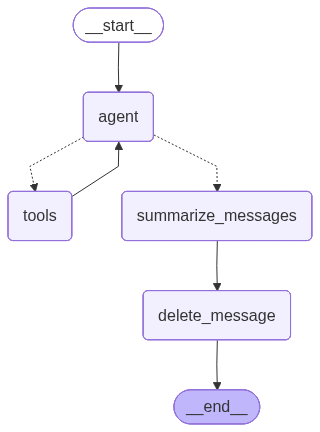

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

# query = 'what currency is in Billy Giles\' birthplace? Find the currency and email it to cleftin02@gamil.com'
# query = 'Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보낼 겁니다. 우선 이메일 보낼낼 초안을 작성해 주세요'
query = '일반인이 1주택이며, 집이 15억 일 때 종합부동산세를 추정으로로 계산해 줄 수 있나요?'

for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

일반인이 1주택이며, 집이 15억 일 때 종합부동산세를 추정으로로 계산해 줄 수 있나요?
messages length == 1
agent_messages_with_summary == [HumanMessage(content='일반인이 1주택이며, 집이 15억 일 때 종합부동산세를 추정으로로 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='621c5a29-4f9d-498a-ae39-33391af97e43')]
should_continue messages == [HumanMessage(content='일반인이 1주택이며, 집이 15억 일 때 종합부동산세를 추정으로로 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='621c5a29-4f9d-498a-ae39-33391af97e43'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 859, 'total_tokens': 918, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'i

In [26]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 2838, 'total_tokens': 2901, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXRIzRpjWtrP6z4i0NeEgG3L2a8XX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db53c-dbea-72a3-8db3-6699ca06137b-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '주택분 종합부동산세 2주택 이하 세율 과세표준 구간 2026 1세대1주택 공정시장가액비율 60%'}, 'id': 'call_jUVNorlP9TEUmlKZPYoLZTht', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2838, 'output_tokens': 63, 'total_tokens': 2901, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

In [27]:
graph.get_state(config).values['summary']

'The chat was about estimating Korea’s **종합부동산세 (comprehensive real estate tax)** for an ordinary person who owns **one home valued at 15억**.\n\nKey points covered:\n- The assistant first checked the relevant tax law using a real-estate tax retrieval tool.\n- It noted that **종부세 is based on 공시가격 (official assessed value)**, not market price, so “15억” could mean either **공시가격** or **market price**, which would change the result.\n- For the estimate, it assumed:\n  - **1세대 1주택**\n  - **공시가격 15억**\n  - No special deductions such as **고령자 공제** or **장기보유 공제**\n\nEstimated calculation:\n- 공시가격 15억\n- Minus 1주택 deduction of 12억\n- Tax base after deduction: **3억**\n- Apply 공정시장가액비율 60% → **과세표준 1억 8천만 원**\n- Apply 0.5% tax rate → **종부세 약 90만 원**\n- Add 농어촌특별세 20% → **약 18만 원**\n- **Total estimated burden: 약 108만 원**\n\nThe assistant concluded:\n- **종부세 본세: 약 90만 원**\n- **농어촌특별세 포함 총액: 약 108만 원 전후**\n- Actual tax can vary depending on whether 15억 is market price or official price, and on additi

In [41]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

update_query = '11년 보유했어어'

for chunk in graph.stream({'messages': [HumanMessage(update_query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

11년 보유했어어
messages length == 4
agent_messages_with_summary == [AIMessage(content='그럼 조건은 이렇게 보겠습니다.\n\n- **1세대 1주택**\n- **단독명의**\n- **50세**\n- **11년 보유**\n- 앞서와 동일하게 **공시가격 15억** 가정\n\n## 결론\n50세이면 **고령자 공제는 없음**이고,  \n**장기보유 공제 40%만 적용**됩니다.\n\n그래서 이전 계산과 거의 같습니다.\n\n- **종부세 본세:** 약 **54만 원**\n- **농어촌특별세:** 약 **10.8만 원**\n- **총 부담:** 약 **64.8만 원**\n\n즉, **약 65만 원 정도**로 보시면 됩니다.\n\n---\n\n## 왜 그대로냐면\n### 1) 기본세액\n- 공시가격 15억\n- 1세대 1주택 공제 12억\n- 남는 금액 3억\n- 공정시장가액비율 60% 적용\n- 과세표준 **1억 8천만 원**\n\n### 2) 세율\n- 과세표준 3억 이하 구간\n- 세율 **0.5%**\n\n→ 산출세액 **90만 원**\n\n### 3) 세액공제\n- 11년 보유 → **장기보유 40% 공제**\n- 50세 → **고령자 공제 없음**\n\n→ 90만 원 × (1 - 0.4) = **54만 원**\n\n### 4) 농어촌특별세\n- 54만 원 × 20% = **10.8만 원**\n\n→ 합계 **64.8만 원**\n\n---\n\n## 한 줄 요약\n**공시가격 15억짜리 1주택을 단독명의로 11년 보유한 50세라면, 종부세 총액은 대략 65만 원 정도로 추정됩니다.**\n\n원하시면 제가 다음으로  \n**“공시가격이 아니라 시가 15억일 때는 얼마인지”**도 계산해드릴게요.', additional_kwargs={'refusal': None}

In [42]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='네. 그 조건이면:\n\n- **단독명의**\n- **50세**\n- **11년 보유**\n- **1세대 1주택**\n- **공시가격 15억 기준**\n\n### 추정 종부세\n- **본세:** 약 **54만 원**\n- **농어촌특별세 포함 총액:** 약 **65만 원**\n\n### 이유\n- **50세**라서 **고령자 공제는 없음**\n- **11년 보유**라서 **장기보유 공제 40%** 적용\n\n즉, **최종적으로 약 65만 원 전후**로 보면 됩니다.\n\n원하시면 제가 이걸 **딱 한 줄로만**도 정리해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 2222, 'total_tokens': 2388, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXRKbTomSqjGqq46jQJeneN5Y4xZ3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019db53e-60f7-7f22-8af4-1c12caa1e8c2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [44]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

update_query = '단독 명의이고 50세입니다.'

for chunk in graph.stream({'messages': [HumanMessage(update_query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

단독 명의이고 50세입니다.
messages length == 4
agent_messages_with_summary == [AIMessage(content='네. 그 조건이면:\n\n- **단독명의**\n- **50세**\n- **11년 보유**\n- **1세대 1주택**\n- **공시가격 15억 기준**\n\n### 추정 종부세\n- **본세:** 약 **54만 원**\n- **농어촌특별세 포함 총액:** 약 **65만 원**\n\n### 이유\n- **50세**라서 **고령자 공제는 없음**\n- **11년 보유**라서 **장기보유 공제 40%** 적용\n\n즉, **최종적으로 약 65만 원 전후**로 보면 됩니다.\n\n원하시면 제가 이걸 **딱 한 줄로만**도 정리해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 2222, 'total_tokens': 2388, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXRKbTomSqjGqq46jQJeneN5Y4xZ3', 'service_tier': 'default', 'finish_reaso

In [45]:
graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='네. 그 조건이면:\n\n- **단독명의**\n- **50세**\n- **11년 보유**\n- **1세대 1주택**\n- **공시가격 15억 기준**\n\n### 추정 종부세\n- **본세:** 약 **54만 원**\n- **농어촌특별세 포함 총액:** 약 **65만 원**\n\n### 이유\n- **50세**라서 **고령자 공제는 없음**\n- **11년 보유**라서 **장기보유 공제 40%** 적용\n\n즉, **최종적으로 약 65만 원 전후**로 보면 됩니다.\n\n원하시면 제가 이걸 **딱 한 줄로만**도 정리해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 2222, 'total_tokens': 2388, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXRKbTomSqjGqq46jQJeneN5Y4xZ3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019db53e-60f7-7f22-8af4-1c12caa1e8c2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [32]:
# from langchain_core.messages import HumanMessage

# graph.invoke({'messages': [HumanMessage('3에다 5를 더하고 거기에 8을 곱하면?')]})

In [33]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list

In [34]:
# from langchain_core.messages import RemoveMessage

# for index, message in enumerate(current_message_list):
#     if index < len(current_message_list) - 1:
#         graph.update_state(config, {'messages': RemoveMessage(id=message.id)})

In [35]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list